In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Read a dataset and make first fixes (data types, nans)

In [21]:
df = pd.read_parquet('data/transactions/transactions_2017.parquet')
df

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,_source_file,МесяцДатыЗаказа
0,01.01.2017 17:15,2017-01-04,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00023865048,0,None,!01_02_17_VSE.csv,NaN
1,01.01.2017 17:15,2017-01-04,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00022519452,0,None,!01_02_17_VSE.csv,NaN
2,01.01.2017 17:38,2017-01-03,3530303_TR,К отгрузке,3 585,3 585,Курьерская,Наличная,Москва,ПОДГУЗНИКИ,...,0,01.01.2017 0:00,55574851-55555555555176,49117_1u16@mail.ru,Anastasia,IDL00038454553,0,None,!01_02_17_VSE.csv,NaN
3,01.01.2017 17:38,2017-01-04,3530318_TR,Доставлен,2 510,2 510,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1,02.01.2017 0:00,55575054-56575354545171,115117_su21@mail.ru,Гость,IDL00035301654,0,None,!01_02_17_VSE.csv,NaN
4,01.01.2017 17:38,2017-01-02,3530313_TR,К отгрузке,1 069,1 069,Самовывоз,Наличная,Санкт-Петербург,ИГРУШКИ,...,1,02.01.2017 0:00,55575149-50524951545076,106117_ju18@yandex.ru,Гость,ID9010025983048,0,None,!01_02_17_VSE.csv,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4122216,30.12.2017 17:46,2017-12-31,6940004_TR,К отгрузке,1 458,1 458,Самовывоз,Наличная,Санкт-Петербург,ИГРУШКИ,...,1,30.12.2017 0:00,None,None,None,None,None,None,!12_17_VSE.csv,12.0
4122217,30.12.2017 18:10,2017-12-31,6940146_TR,Отменен,6 799,0,Самовывоз,Наличная,Нижневартовск,КРУПНОГАБАРИТНЫЙ ТОВАР,...,1,30.12.2017 0:00,None,None,None,None,None,None,!12_17_VSE.csv,12.0
4122218,30.12.2017 18:33,2017-12-31,6940306_TR,Отменен,2 419,0,Самовывоз,Наличная,Казань,ИГРУШКИ,...,1,30.12.2017 0:00,None,None,None,None,None,None,!12_17_VSE.csv,12.0
4122219,30.12.2017 19:19,2017-12-31,6940589_TR,Отменен,5 248,0,Самовывоз,Наличная,Нижний Новгород,КРУПНОГАБАРИТНЫЙ ТОВАР,...,1,30.12.2017 0:00,None,None,None,None,None,None,!12_17_VSE.csv,12.0


In [22]:
df["Дата"] = pd.to_datetime(df["Дата"], dayfirst=True, errors="coerce")

In [23]:
df['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

ДатаДоставки
2017-01    205595
2017-02    280810
2017-03    291313
2017-04    331846
2017-05    293737
2017-06    356324
2017-07    290397
2017-08    409531
2017-09    303472
2017-10    449998
2017-11    400037
2017-12    509161
Freq: M, Name: count, dtype: int64

In [24]:
df['Дата'].dt.to_period('M').value_counts().sort_index()

Дата
2017-01    285139
2017-02    201266
2017-03    338186
2017-04    284973
2017-05    381061
2017-06    269000
2017-07    375704
2017-08    324224
2017-09    390769
2017-10    362701
2017-11    400037
2017-12    509161
Freq: M, Name: count, dtype: int64

In [25]:
s = df['Телефон_new'].astype(str)
mask_dash = s.str.match(r'^\d+-\d+$')
mask_digits = s.str.match(r'^\d+$')
mask_date = s.str.match(r'^\d{2}\.\d{2}\.\d{4}')
mask_other = ~(mask_dash | mask_digits | mask_date)
n = len(s)

print("dash format:", mask_dash.sum(), mask_dash.mean())
print("digits only:", mask_digits.sum(), mask_digits.mean())
print("date-like :", mask_date.sum(), mask_date.mean())
print("other     :", mask_other.sum(), mask_other.mean())

dash format: 3202743 0.7769459716012315
digits only: 16371 0.003971402794755546
date-like : 1326 0.000321671254403876
other     : 901781 0.2187609543496091


In [26]:
print("---- dash ----")
print(s[mask_dash].head(5))

print("---- digits ----")
print(s[mask_digits].head(5))

print("---- date ----")
print(s[mask_date].head(5))

print("---- other ----")
print(s[mask_other].head(50))

---- dash ----
0    55575454-49504949555170
1    55575454-49504949555170
2    55574851-55555555555176
3    55575054-56575354545171
4    55575149-50524951545076
Name: Телефон_new, dtype: object
---- digits ----
984     0
1001    0
1608    0
2141    0
2149    0
Name: Телефон_new, dtype: object
---- date ----
3216478    21.11.2017 9:59
3216479    21.11.2017 9:59
3216480    21.11.2017 9:59
3216481    21.11.2017 9:59
3216483    21.11.2017 9:59
Name: Телефон_new, dtype: object
---- other ----
357760     71764848-484951505252G4
380412     71764848-485153555450G6
912229     71764848-485149524951G3
962207     32555749-545749525150 .
962702     71764848-485149524951G3
1030356    32555749-545749525150 .
1030357    32555749-545749525150 .
1030373    32555749-545749525150 .
1030374    32555749-545749525150 .
1030396    32555749-545749525150 .
3011499    32565748-535549565054 5
3011500    32565748-535549565054 5
3011501    32565748-535549565054 5
3017952    53555356-5652499566885X
3017953    5355535

In [27]:
s = df['Телефон_new'].astype(str).str.strip()

mask_date = s.str.match(r'^\d{2}\.\d{2}\.\d{4}\s+\d{1,2}:\d{2}$')
print("Date-like rows:", mask_date.sum())
print("Share:", mask_date.mean())

Date-like rows: 1326
Share: 0.000321671254403876


In [28]:
df = df.loc[~mask_date].copy()

In [29]:
df['Телефон_new'].astype(str).str.match(
    r'^\d{2}\.\d{2}\.\d{4}\s+\d{1,2}:\d{2}$'
).sum()

0

In [30]:
# Пофиксила тип числовых значений
numeric_columns = [
    'СуммаЗаказаНаСайте', 
    'СуммаДокумента', 
    'Цена', 
    'СуммаСтроки', 
    'ЦенаЗакупки', 
    'Маржа', 
    'СуммаУслуг', 
    'СуммаДоставки']    
    
for col in numeric_columns:
    df[col] = (df[col]
                    .astype(str)
                    .str.replace('\xa0', '', regex=False)  # на всякий случай
                    .str.replace(' ', '', regex=False)
                    .str.replace(',', '.', regex=False))
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
# тип даты
df["Дата"] = pd.to_datetime(df["Дата"], dayfirst=True, errors="coerce")
df["ДатаДоставки"] = pd.to_datetime(df["ДатаДоставки"], dayfirst=True, errors="coerce")
df["ДатаЗаказаНаСайте"] = pd.to_datetime(df["ДатаЗаказаНаСайте"], dayfirst=True, errors="coerce")

df['МетодДоставки'] = (
    df['МетодДоставки']
    .astype(str)         
    .str.strip()         
    .str.lower()
)

df['ФормаОплаты'] = (
    df['ФормаОплаты']
    .astype(str)
    .str.strip()
    .str.lower()
)


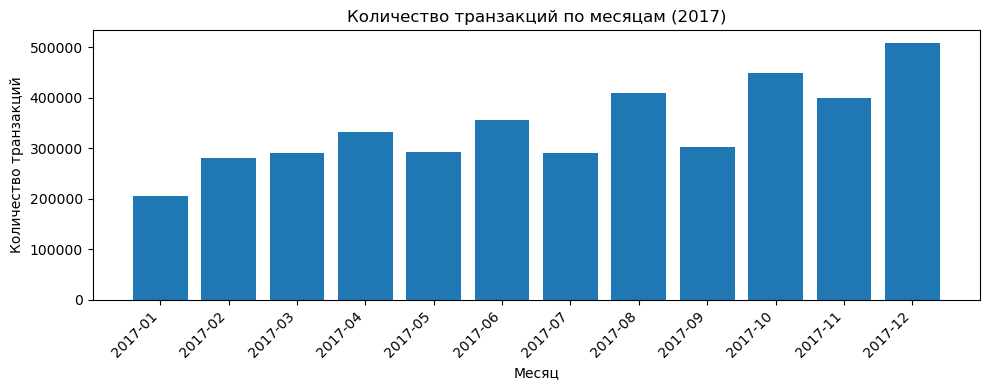

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

monthly_counts = (
    df["ДатаДоставки"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

x = monthly_counts.index.astype(str)   # '2017-01', ...
y = monthly_counts.values

plt.figure(figsize=(10,4))
plt.bar(x, y)
plt.title("Количество транзакций по месяцам (2017)")
plt.xlabel("Месяц")
plt.ylabel("Количество транзакций")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

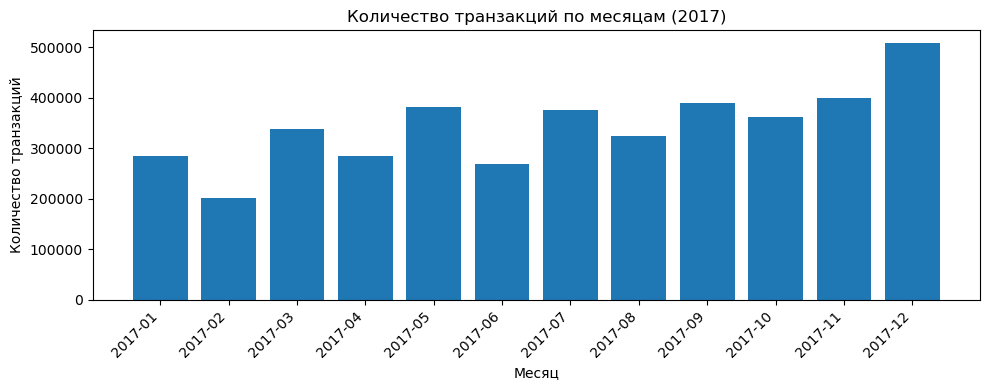

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

monthly_counts = (
    df["Дата"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

x = monthly_counts.index.astype(str)   # '2017-01', ...
y = monthly_counts.values

plt.figure(figsize=(10,4))
plt.bar(x, y)
plt.title("Количество транзакций по месяцам (2017)")
plt.xlabel("Месяц")
plt.ylabel("Количество транзакций")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

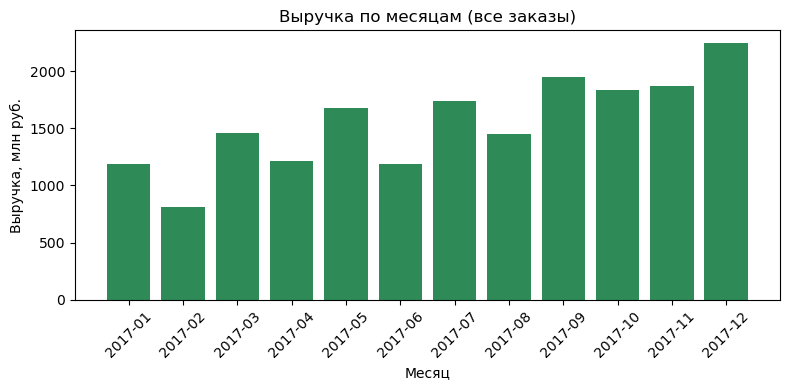

In [33]:
# Выручка по месяцам (все заказы)
revenue = (
    df.groupby(df["Дата"].dt.to_period("M"))["СуммаЗаказаНаСайте"]
    .apply(lambda x: pd.to_numeric(x, errors="coerce").sum())
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(revenue.index.astype(str), revenue.values / 1e6, color="seagreen")
plt.title("Выручка по месяцам (все заказы)")
plt.xlabel("Месяц")
plt.ylabel("Выручка, млн руб.")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


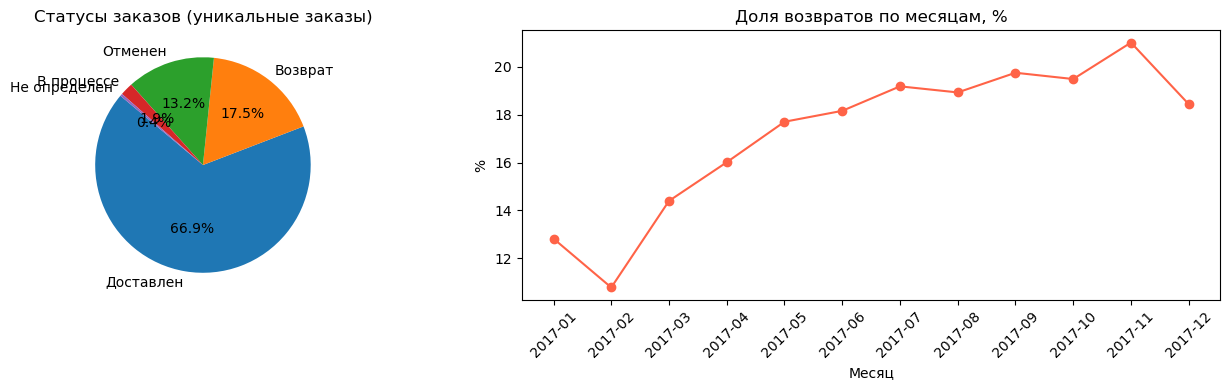

In [34]:
# Статусы заказов и доля отмен по месяцам
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pie: статусы
status_counts = df.groupby("Статус")["НомерЗаказаНаСайте"].nunique().sort_values(ascending=False)
axes[0].pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=140)
axes[0].set_title("Статусы заказов (уникальные заказы)")

# Доля возвратов по месяцам
monthly_all = df.groupby(df["Дата"].dt.to_period("M"))["НомерЗаказаНаСайте"].nunique()
monthly_ret = df[df["Статус"] == "Возврат"].groupby(df[df["Статус"] == "Возврат"]["Дата"].dt.to_period("M"))["НомерЗаказаНаСайте"].nunique()
return_rate = (monthly_ret / monthly_all * 100).sort_index().dropna()

axes[1].plot(return_rate.index.astype(str), return_rate.values, marker="o", color="tomato")
axes[1].set_title("Доля возвратов по месяцам, %")
axes[1].set_xlabel("Месяц")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

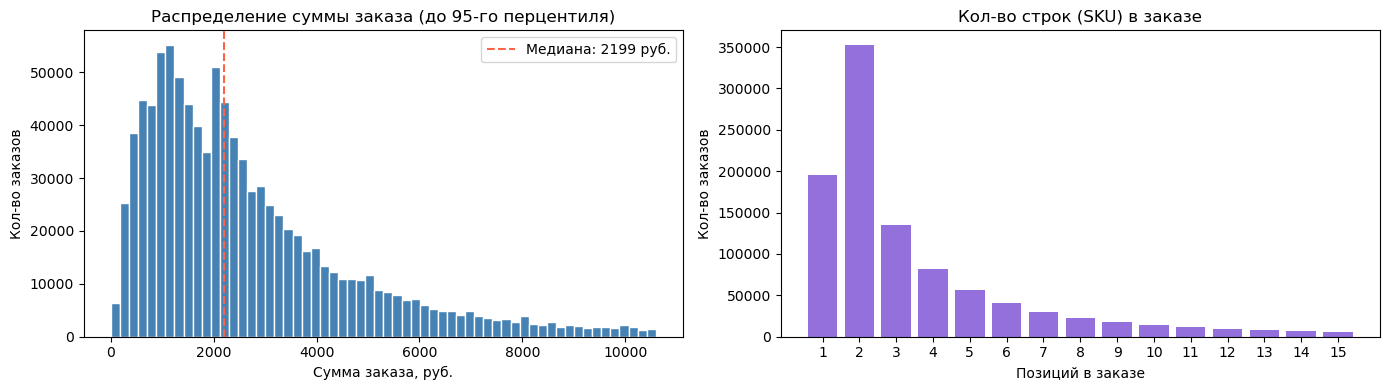

Медиана суммы заказа: 2199 руб.
Средняя сумма заказа: 3494 руб.


In [35]:
# Распределение суммы заказа и кол-ва позиций в заказе
df["СуммаЗаказаНаСайте"] = pd.to_numeric(df["СуммаЗаказаНаСайте"], errors="coerce")

orders = df.groupby("НомерЗаказаНаСайте").agg(
    сумма=("СуммаЗаказаНаСайте", "first"),
    позиций=("НомерЗаказаНаСайте", "count")
)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Сумма заказа (до 15 000 руб. — 95-й перцентиль)
p95 = orders["сумма"].quantile(0.95)
axes[0].hist(orders[orders["сумма"] <= p95]["сумма"], bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(orders["сумма"].median(), color="tomato", linestyle="--", label=f"Медиана: {orders["сумма"].median():.0f} руб.")
axes[0].set_title("Распределение суммы заказа (до 95-го перцентиля)")
axes[0].set_xlabel("Сумма заказа, руб.")
axes[0].set_ylabel("Кол-во заказов")
axes[0].legend()

# Кол-во позиций в заказе
pos_counts = orders["позиций"].value_counts().sort_index().head(15)
axes[1].bar(pos_counts.index.astype(str), pos_counts.values, color="mediumpurple")
axes[1].set_title("Кол-во строк (SKU) в заказе")
axes[1].set_xlabel("Позиций в заказе")
axes[1].set_ylabel("Кол-во заказов")

plt.tight_layout()
plt.show()

print(f"Медиана суммы заказа: {orders["сумма"].median():.0f} руб.")
print(f"Средняя сумма заказа: {orders["сумма"].mean():.0f} руб.")

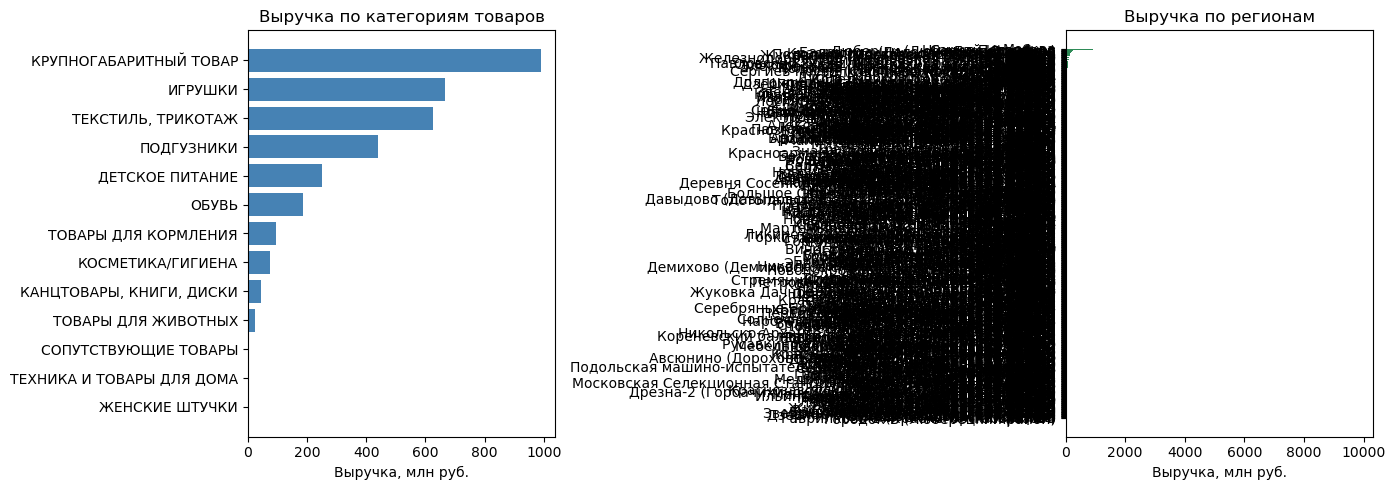

In [36]:
df["СуммаСтроки"] = pd.to_numeric(df["СуммаСтроки"], errors="coerce")
# Категории товаров и регионы
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Группа2 — горизонтальный bar
cat = df.groupby("Группа2")["СуммаСтроки"].sum().sort_values()
axes[0].barh(cat.index, cat.values / 1e6, color="steelblue")
axes[0].set_title("Выручка по категориям товаров")
axes[0].set_xlabel("Выручка, млн руб.")

# Регионы
reg = df.groupby("Регион")["СуммаЗаказаНаСайте"].sum().sort_values()
axes[1].barh(reg.index, reg.values / 1e6, color="seagreen")
axes[1].set_title("Выручка по регионам")
axes[1].set_xlabel("Выручка, млн руб.")

plt.tight_layout()
plt.show()

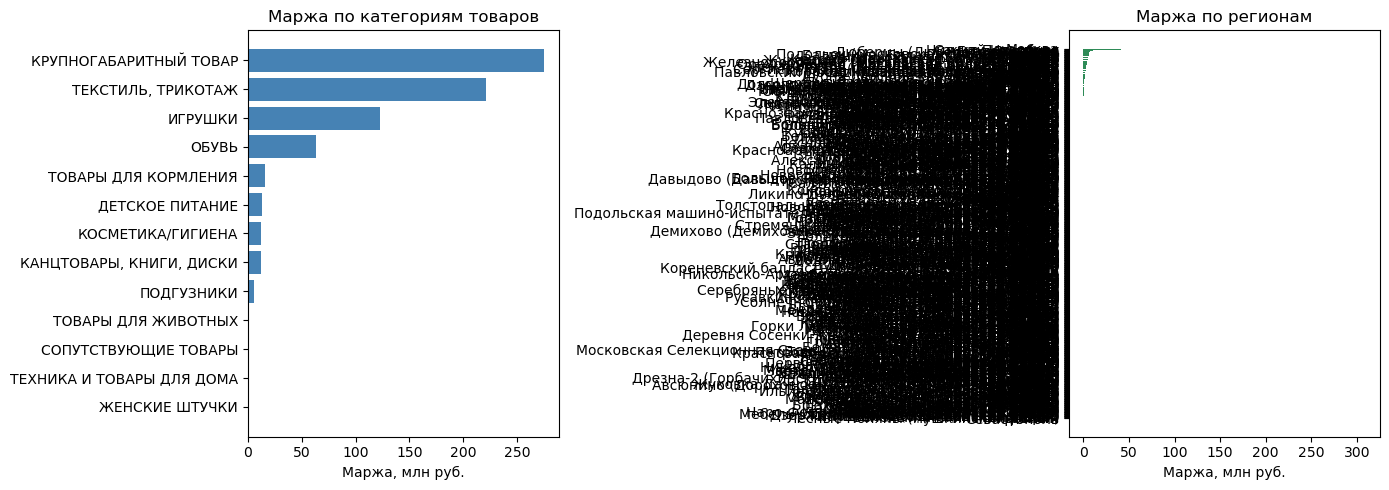

In [37]:
df["Маржа"] = pd.to_numeric(df["Маржа"], errors="coerce")
# Маржа по категориям и регионам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Группа2 — горизонтальный bar
cat = df.groupby("Группа2")["Маржа"].sum().sort_values()
axes[0].barh(cat.index, cat.values / 1e6, color="steelblue")
axes[0].set_title("Маржа по категориям товаров")
axes[0].set_xlabel("Маржа, млн руб.")

# Регионы
reg = df.groupby("Регион")["Маржа"].sum().sort_values()
axes[1].barh(reg.index, reg.values / 1e6, color="seagreen")
axes[1].set_title("Маржа по регионам")
axes[1].set_xlabel("Маржа, млн руб.")

plt.tight_layout()
plt.show()


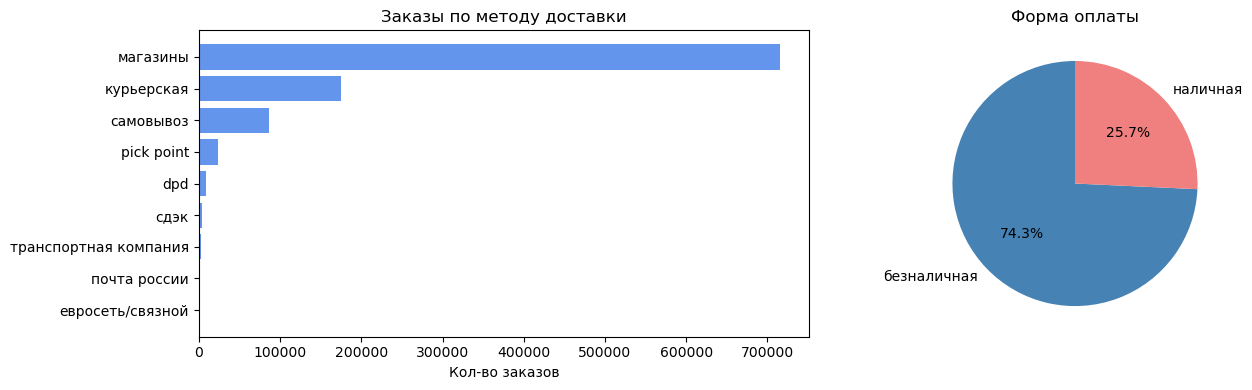

In [38]:
# Метод доставки и форма оплаты
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Метод доставки
deliv = df.groupby("МетодДоставки")["НомерЗаказаНаСайте"].nunique().sort_values()
axes[0].barh(deliv.index, deliv.values, color="cornflowerblue")
axes[0].set_title("Заказы по методу доставки")
axes[0].set_xlabel("Кол-во заказов")

# Форма оплаты
pay = df.groupby("ФормаОплаты")["НомерЗаказаНаСайте"].nunique()
axes[1].pie(pay, labels=pay.index, autopct="%1.1f%%", startangle=90, colors=["steelblue", "lightcoral"])
axes[1].set_title("Форма оплаты")

plt.tight_layout()
plt.show()

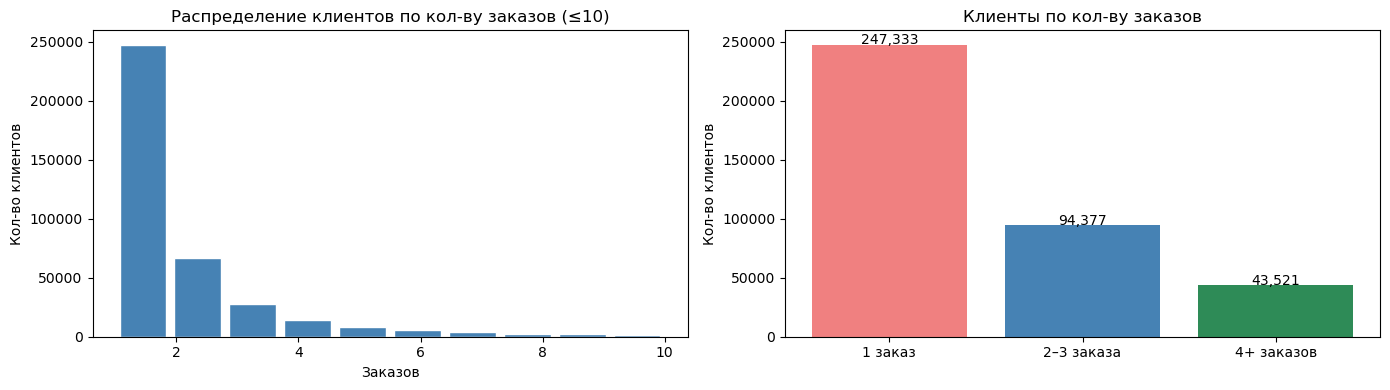

Клиентов с 1 заказом: 247,333 (64.2%)
Клиентов с 4+ заказами: 43,521 (11.3%)


In [39]:
# Распределение клиентов по частоте заказов (основа для RFM)
client_orders = df.groupby("Телефон_new")["НомерЗаказаНаСайте"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма (до 10 заказов — 90%+ клиентов)
axes[0].hist(client_orders[client_orders <= 10], bins=10, color="steelblue", edgecolor="white", rwidth=0.85)
axes[0].set_title("Распределение клиентов по кол-ву заказов (≤10)")
axes[0].set_xlabel("Заказов")
axes[0].set_ylabel("Кол-во клиентов")

# Разбивка: 1 / 2-3 / 4+ заказов
buckets = pd.cut(client_orders, bins=[0, 1, 3, client_orders.max()], labels=["1 заказ", "2–3 заказа", "4+ заказов"])
bucket_counts = buckets.value_counts().sort_index()
axes[1].bar(bucket_counts.index, bucket_counts.values, color=["lightcoral", "steelblue", "seagreen"])
axes[1].set_title("Клиенты по кол-ву заказов")
axes[1].set_ylabel("Кол-во клиентов")
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

one_time = (client_orders == 1).sum()
print(f"Клиентов с 1 заказом: {one_time:,} ({one_time/len(client_orders)*100:.1f}%)")
print(f"Клиентов с 4+ заказами: {(client_orders >= 4).sum():,} ({(client_orders >= 4).sum()/len(client_orders)*100:.1f}%)")

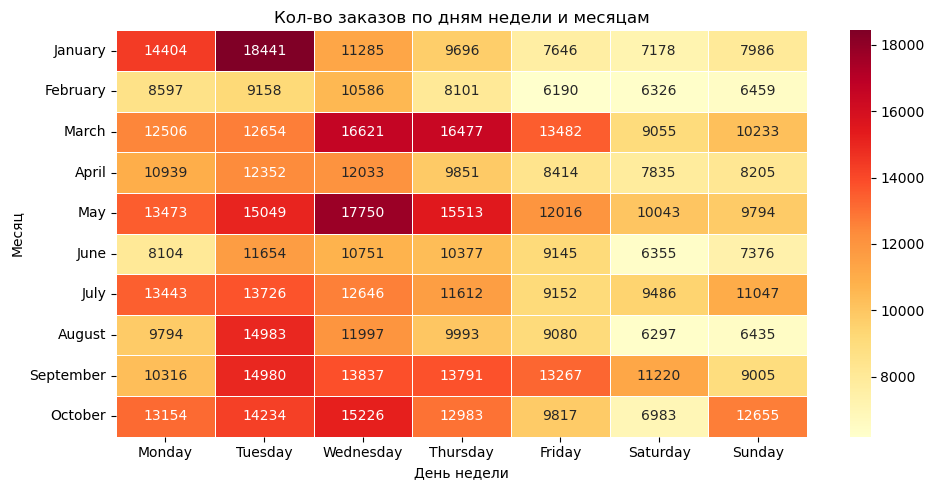

In [40]:
# Тепловая карта: активность по дням недели и месяцам
pivot = (
    df.groupby([df["Дата"].dt.month_name(), df["Дата"].dt.day_name()])
    ["НомерЗаказаНаСайте"].nunique()
    .unstack()
)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October"]
day_order   = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pivot.reindex(index=month_order, columns=day_order)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.4)
plt.title("Кол-во заказов по дням недели и месяцам")
plt.xlabel("День недели")
plt.ylabel("Месяц")
plt.tight_layout()
plt.show()

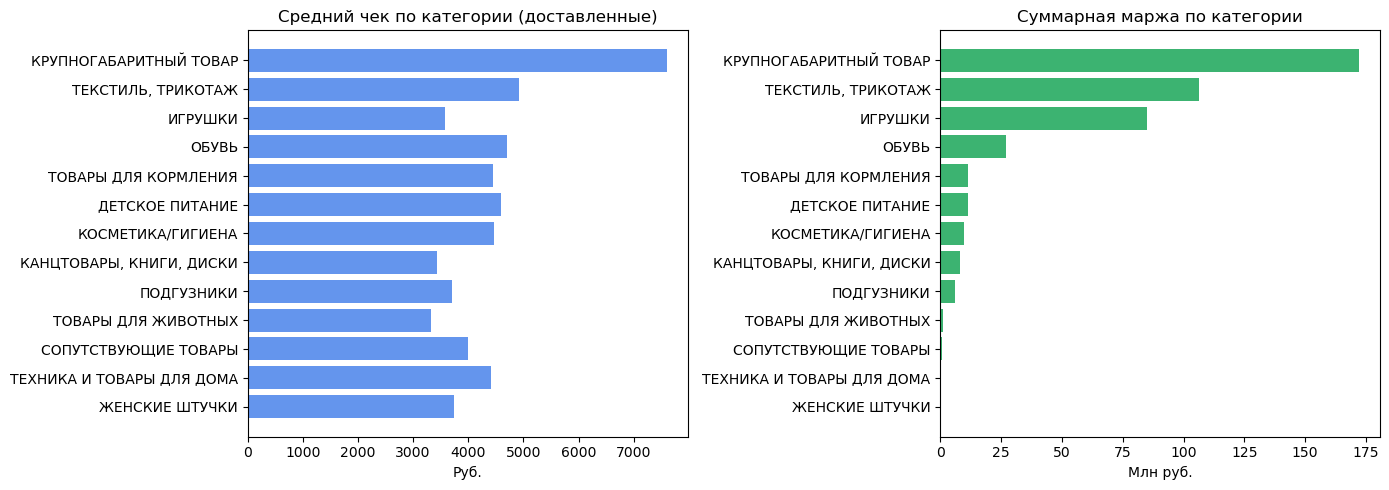

In [41]:
# Средний чек и маржа по категориям товаров
cat_stats = (
    df[df["Статус"] == "Доставлен"]
    .groupby("Группа2")
    .agg(
        средний_чек=("СуммаЗаказаНаСайте", "mean"),
        маржа_итого=("Маржа", "sum"),
    )
    .sort_values("маржа_итого", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(cat_stats.index, cat_stats["средний_чек"], color="cornflowerblue")
axes[0].set_title("Средний чек по категории (доставленные)")
axes[0].set_xlabel("Руб.")

axes[1].barh(cat_stats.index, cat_stats["маржа_итого"] / 1e6, color="mediumseagreen")
axes[1].set_title("Суммарная маржа по категории")
axes[1].set_xlabel("Млн руб.")

plt.tight_layout()
plt.show()

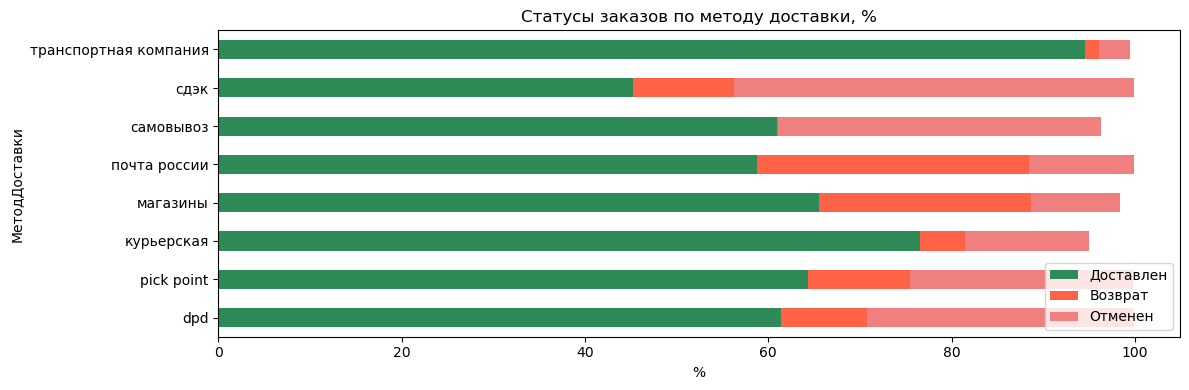

In [42]:
# Доля отмен и возвратов по методу доставки
status_deliv = (
    df.groupby(["МетодДоставки", "Статус"])["НомерЗаказаНаСайте"]
    .nunique()
    .unstack(fill_value=0)
)
status_pct = status_deliv.div(status_deliv.sum(axis=1), axis=0) * 100

significant = status_deliv.sum(axis=1)[status_deliv.sum(axis=1) > 1000].index
status_pct = status_pct.loc[significant]

status_pct[["Доставлен", "Возврат", "Отменен"]].plot(
    kind="barh", stacked=True, figsize=(12, 4),
    color=["seagreen", "tomato", "lightcoral"]
)
plt.title("Статусы заказов по методу доставки, %")
plt.xlabel("%")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

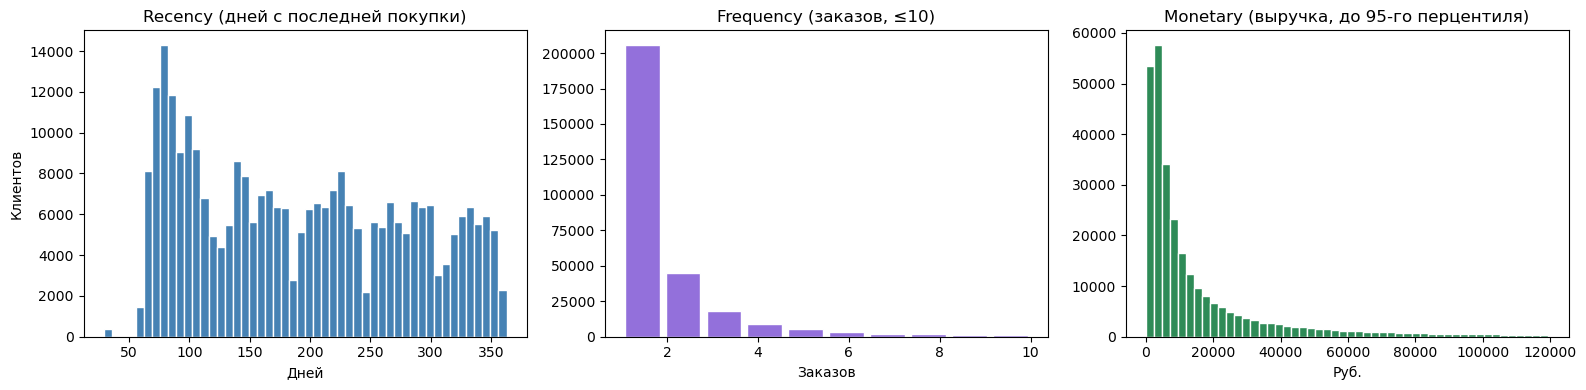

        recency  frequency    monetary
count  294783.0   294783.0    294783.0
mean      191.9        1.8     31683.0
std        89.2        2.6    125133.4
min        29.0        1.0         1.0
25%       107.0        1.0      3078.0
50%       181.0        1.0      7345.0
75%       269.0        2.0     21210.0
max       363.0      932.0  13049632.0


In [43]:
# RFM-компоненты: предварительные распределения по клиентам
snapshot = df["Дата"].max()

rfm = (
    df[df["Статус"] == "Доставлен"]
    .groupby("Телефон_new")
    .agg(
        recency=("Дата", lambda x: (snapshot - x.max()).days),
        frequency=("НомерЗаказаНаСайте", "nunique"),
        monetary=("СуммаЗаказаНаСайте", "sum"),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["recency"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Recency (дней с последней покупки)")
axes[0].set_xlabel("Дней")
axes[0].set_ylabel("Клиентов")

axes[1].hist(rfm[rfm["frequency"] <= 10]["frequency"], bins=10,
             color="mediumpurple", edgecolor="white", rwidth=0.85)
axes[1].set_title("Frequency (заказов, ≤10)")
axes[1].set_xlabel("Заказов")

p95 = rfm["monetary"].quantile(0.95)
axes[2].hist(rfm[rfm["monetary"] <= p95]["monetary"], bins=50,
             color="seagreen", edgecolor="white")
axes[2].set_title("Monetary (выручка, до 95-го перцентиля)")
axes[2].set_xlabel("Руб.")

plt.tight_layout()
plt.show()

print(rfm.describe().round(1))

In [44]:
# Пофиксила тип числовых значений
numeric_columns = [
    'СуммаЗаказаНаСайте', 
    'СуммаДокумента', 
    'Цена', 
    'СуммаСтроки', 
    'ЦенаЗакупки', 
    'Маржа', 
    'СуммаУслуг', 
    'СуммаДоставки']    
    
for col in numeric_columns:
    df[col] = (df[col]
                    .astype(str)
                    .str.replace('\xa0', '', regex=False)  # на всякий случай
                    .str.replace(' ', '', regex=False)
                    .str.replace(',', '.', regex=False))
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
# тип даты
df["Дата"] = pd.to_datetime(df["Дата"], dayfirst=True, errors="coerce")
df["ДатаДоставки"] = pd.to_datetime(df["ДатаДоставки"], dayfirst=True, errors="coerce")
df["ДатаЗаказаНаСайте"] = pd.to_datetime(df["ДатаЗаказаНаСайте"], dayfirst=True, errors="coerce")

df['МетодДоставки'] = (
    df['МетодДоставки']
    .astype(str)         
    .str.strip()         
    .str.lower()
)

df['ФормаОплаты'] = (
    df['ФормаОплаты']
    .astype(str)
    .str.strip()
    .str.lower()
)


In [45]:
df.dtypes

Дата                        datetime64[ns]
ДатаДоставки                datetime64[ns]
НомерЗаказаНаСайте                  object
НовыйСтатус                         object
СуммаЗаказаНаСайте                 float64
СуммаДокумента                     float64
МетодДоставки                       object
ФормаОплаты                         object
Регион                              object
Группа2                             object
Группа3                             object
Группа4                             object
Тип                                 object
Номенклатура                        object
ТипТовара                           object
Отменено                            object
ПричинаОтмены                       object
Количество                           int64
Цена                               float64
СуммаСтроки                        float64
ЦенаЗакупки                        float64
МесяцДаты Заказа                   float64
ГодДатыЗаказа                       object
ПВЗ_код    

In [46]:
df['Телефон_new'].value_counts()

Телефон_new
0                          16371
55575455-48575054505274      866
55575053-56495253555476      839
55575055-51485353525070      800
55575456-52545049485371      786
                           ...  
55575653-55535450495678        1
55575449-55535553514971        1
55574953-53565757575476        1
55574952-51545351534870        1
55575055-56485556495677        1
Name: count, Length: 385231, dtype: int64

In [47]:
df['Телефон_new'].dtype

dtype('O')

In [48]:
df['Телефон_new'].map(type).value_counts().head(10)

Телефон_new
<class 'str'>         3219142
<class 'NoneType'>     901753
Name: count, dtype: int64

In [49]:
s = df['Телефон_new']
print("NaN:", s.isna().sum())
print("==0 (число):", (s == 0).sum())
print("=='0' (строка):", (s.astype(str) == '0').sum())
print("=='None' (строка):", (s.astype(str).str.lower() == 'none').sum())
print("пустая строка:", (s.astype(str).str.strip() == '').sum())

NaN: 901753
==0 (число): 0
=='0' (строка): 16371
=='None' (строка): 901753
пустая строка: 0


In [50]:
# 1) убираем настоящие пропуски (None/NaN)
df = df[df['Телефон_new'].notna()].copy()

# 2) убираем строковые мусорные значения
df['Телефон_new'] = df['Телефон_new'].astype(str).str.strip()
df = df[df['Телефон_new'] != '0'].copy()

# если вдруг реально встречается строка 'None' в данных (после str):
df = df[df['Телефон_new'].str.lower() != 'none'].copy()

In [51]:
# удалила все строки с "Доставка" в столбце "Номенклатура" и "Группа2
df = df[(df['Номенклатура'] != 'Доставка') & (df['Группа2'] != 'Доставка')].copy()

In [52]:
df.shape

(2732793, 40)

In [53]:
new_order = [
    # Клиент
    "Телефон_new",
    
    # Даты / статусы
    "НомерЗаказаНаСайте",
    "Дата",
    "ДатаДоставки",
    "ГодДатыЗаказа",
    "НовыйСтатус",
    "Статус",

    # Логистика / оплата / регион
    "МетодДоставки",
    "ФормаОплаты",
    "Регион",
    "ГородМагазина",

    # Категории товаров
    "Группа2",
    "Группа3",
    "Тип",
    "Номенклатура",

    # Продажи и количество
    "Отменено",
    "Количество",
    "КоличествоПроданоКлиенту",
    "ПричинаОтмены",

    # Финансы
    "Цена",
    "ЦенаЗакупки",
    "СуммаСтроки",
    "СуммаЗаказаНаСайте",
    "Маржа",
    "СуммаУслуг",
    "СуммаДоставки",
    
]

df = df[new_order]
df.head(1)

,Телефон_new,НомерЗаказаНаСайте,Дата,ДатаДоставки,ГодДатыЗаказа,НовыйСтатус,Статус,МетодДоставки,ФормаОплаты,Регион,...,Количество,КоличествоПроданоКлиенту,ПричинаОтмены,Цена,ЦенаЗакупки,СуммаСтроки,СуммаЗаказаНаСайте,Маржа,СуммаУслуг,СуммаДоставки
0,55575454-49504949555170,3530280_TR,2017-01-01 17:15:00,2017-01-04,2 017,Возврат из ПВЗ,Возврат,магазины,безналичная,Москва,...,1,0,None,1400.0,1025.13,1400.0,2800.0,374.87,0,0


# Заполнение пропусков

In [54]:
df.shape

(2732793, 26)

In [55]:
df.isnull().sum()

Телефон_new                       0
НомерЗаказаНаСайте                0
Дата                              0
ДатаДоставки                      0
ГодДатыЗаказа                     0
НовыйСтатус                       0
Статус                            0
МетодДоставки                     0
ФормаОплаты                       0
Регион                        18304
ГородМагазина                     0
Группа2                           0
Группа3                           0
Тип                               0
Номенклатура                      0
Отменено                          0
Количество                        0
КоличествоПроданоКлиенту          0
ПричинаОтмены               2430338
Цена                              0
ЦенаЗакупки                   10775
СуммаСтроки                       0
СуммаЗаказаНаСайте                0
Маржа                         10775
СуммаУслуг                        0
СуммаДоставки                     0
dtype: int64

In [56]:
df['Регион'].unique()

array(['Москва', 'Санкт-Петербург',
       'Жуковский (Московская область район)',
       'Подольск (Московская область район)', 'Новосибирск', 'Смоленск',
       'Барнаул', 'Наро-Фоминск (Наро-Фоминский район)', 'Сургут', 'Уфа',
       'Нижний Новгород', 'Омск', 'Тула', 'Саратов', 'Челябинск',
       'Волгоград', 'Липецк', 'Рязань', 'Чита', 'Тамбов', None, 'Тюмень',
       'Екатеринбург', 'Ульяновск', 'Люберцы (Люберецкий район)',
       'Дубна (Московская область район)', 'Ярославль', 'Иркутск',
       'Железнодорожный (Московская область район)', 'Ростов-на-Дону',
       'Пермь', 'Сочи', 'Клин (Клинский район)', 'Краснодар',
       'Сергиев Посад (Сергиево-Посадский район)',
       'Мытищи (Мытищинский район)', 'Казань', 'Самара', 'Тобольск',
       'Истра (Истринский район)', 'Курск', 'Калуга',
       'Королев (Московская область район)',
       'Одинцово (Одинцовский район)', 'Нижневартовск', 'Воронеж',
       'Реутов (Московская область район)', 'Астрахань', 'Новомосковск',
     

In [57]:
df['ГородМагазина'].value_counts()

ГородМагазина
0                 2715262
Москва               3282
Калуга               1276
Ростов-на-Дону        928
Саратов               751
                   ...   
Благовещенск           47
Коломна                46
Стерлитамак            31
Улан-Удэ               31
Люберцы                 5
Name: count, Length: 65, dtype: int64

In [58]:
# удалила ненужные скобки в регионе: "Люберцы (Люберецкий район)" => "Люберцы"
df['Регион'] = df['Регион'].str.replace(r"\s*\(.*?\)", "", regex=True).str.strip()

In [59]:
df['Регион'].unique()

array(['Москва', 'Санкт-Петербург', 'Жуковский', 'Подольск',
       'Новосибирск', 'Смоленск', 'Барнаул', 'Наро-Фоминск', 'Сургут',
       'Уфа', 'Нижний Новгород', 'Омск', 'Тула', 'Саратов', 'Челябинск',
       'Волгоград', 'Липецк', 'Рязань', 'Чита', 'Тамбов', None, 'Тюмень',
       'Екатеринбург', 'Ульяновск', 'Люберцы', 'Дубна', 'Ярославль',
       'Иркутск', 'Железнодорожный', 'Ростов-на-Дону', 'Пермь', 'Сочи',
       'Клин', 'Краснодар', 'Сергиев Посад', 'Мытищи', 'Казань', 'Самара',
       'Тобольск', 'Истра', 'Курск', 'Калуга', 'Королев', 'Одинцово',
       'Нижневартовск', 'Воронеж', 'Реутов', 'Астрахань', 'Новомосковск',
       'Пенза', 'Йошкар-Ола', 'Лобня', 'Архангельск', 'Волжский',
       'Балаково', 'Тольятти', 'Красногорск', 'Оренбург', 'Красноярск',
       'Коломна', 'Кемерово', 'Ижевск', 'Таганрог', 'Владивосток',
       'Балашиха', 'Видное', 'Томск', 'Краснокаменск', 'Орехово-Зуево',
       'Брянск', 'Армавир', 'Белгород', 'Колпино', 'Владимир',
       'Благовещенск'

In [60]:
# NaN в Регион_чистый заменила на ГородМагазина
mask = df['Регион'].isna() & (df['ГородМагазина'] != '0')
df.loc[mask, 'Регион'] = df.loc[mask, 'ГородМагазина']

In [61]:
df = df.rename(columns={'Регион': 'Город'})

In [62]:
df.columns

Index(['Телефон_new', 'НомерЗаказаНаСайте', 'Дата', 'ДатаДоставки',
       'ГодДатыЗаказа', 'НовыйСтатус', 'Статус', 'МетодДоставки',
       'ФормаОплаты', 'Город', 'ГородМагазина', 'Группа2', 'Группа3', 'Тип',
       'Номенклатура', 'Отменено', 'Количество', 'КоличествоПроданоКлиенту',
       'ПричинаОтмены', 'Цена', 'ЦенаЗакупки', 'СуммаСтроки',
       'СуммаЗаказаНаСайте', 'Маржа', 'СуммаУслуг', 'СуммаДоставки'],
      dtype='object')

In [63]:
# таблица с мэтчем город => регион
df_regions = pd.read_excel("data/для_сас_города+_население+мелкие_города.xlsx", sheet_name="население 2014")
df_regions

,Регион,Субъект,Город,Население 2014,Население в городе 2013
0,CENTRAL,Белгородская область,Алексеевка,38626,38979
1,CENTRAL,Белгородская область,Белгород,384425,373528
2,CENTRAL,Белгородская область,Валуйки,34296,34627
3,CENTRAL,Белгородская область,Губкин,87405,87556
4,CENTRAL,Белгородская область,Старый Оскол,221254,220816
...,...,...,...,...,...
652,URAL,Ямало-Ненецкий автономный округ,Надым,45766,48500
653,URAL,Ямало-Ненецкий автономный округ,Новый Уренгой,115092,116450
654,URAL,Ямало-Ненецкий автономный округ,Ноябрьск,107129,108087
655,URAL,Ямало-Ненецкий автономный округ,Салехард,48313,46650


In [64]:
df['Город_clean'] = df['Город'].str.replace(r'\s*\(.*?\)', '', regex=True).str.strip().str.lower()
df_regions['Город_clean'] = df_regions['Город'].str.strip().str.lower()

In [65]:
df['Город_clean'] = df['Город_clean'].str.replace('ё', 'е')
df_regions['Город_clean'] = df_regions['Город_clean'].str.replace('ё', 'е')

In [66]:
manual_mapping = {
    'путилково': 'москва',
    'щербинка': 'москва',
    'наха́бино': 'москва',
    'внуково': 'москва',
    'голицынo': 'москва',
    'мытищи 16': 'мытищи',
    'коммунарка': 'москва',
    'любeрцы–2': 'люберцы',
    'дрозжино': 'москва',
    'ромашково': 'москва',
    'электроугли': 'москва',
    'томилино': 'москва',
    'зеленоград': 'москва',
    'балобаново': 'калуга',
    'севастополь': 'крым',
    'симферополь': 'крым',
    'московский': 'москва',
    'бутово': 'москва',
    'люберцы–2': 'люберцы',
}

In [67]:
df['Город_clean'] = df['Город_clean'].replace(manual_mapping)

In [68]:
df = df.merge(
    df_regions[['Город_clean', 'Регион']],  
    how='left',
    on='Город_clean'
)

In [69]:
df

,Телефон_new,НомерЗаказаНаСайте,Дата,ДатаДоставки,ГодДатыЗаказа,НовыйСтатус,Статус,МетодДоставки,ФормаОплаты,Город,...,ПричинаОтмены,Цена,ЦенаЗакупки,СуммаСтроки,СуммаЗаказаНаСайте,Маржа,СуммаУслуг,СуммаДоставки,Город_clean,Регион
0,55575454-49504949555170,3530280_TR,2017-01-01 17:15:00,2017-01-04,2 017,Возврат из ПВЗ,Возврат,магазины,безналичная,Москва,...,None,1400.0,1025.13,1400.0,2800.0,374.87,0,0,москва,CENTRAL
1,55575454-49504949555170,3530280_TR,2017-01-01 17:15:00,2017-01-04,2 017,Возврат из ПВЗ,Возврат,магазины,безналичная,Москва,...,None,1400.0,1025.13,1400.0,2800.0,374.87,0,0,москва,CENTRAL
2,55574851-55555555555176,3530303_TR,2017-01-01 17:38:00,2017-01-03,2 017,К отгрузке,Доставлен,курьерская,наличная,Москва,...,None,1195.0,1154.25,3585.0,3585.0,122.25,0,0,москва,CENTRAL
3,55575054-56575354545171,3530318_TR,2017-01-01 17:38:00,2017-01-04,2 017,Доставлен,Доставлен,магазины,безналичная,Москва,...,None,2510.0,2227.06,2510.0,2510.0,282.94,0,0,москва,CENTRAL
4,55575149-50524951545076,3530313_TR,2017-01-01 17:38:00,2017-01-02,2 017,К отгрузке,Доставлен,самовывоз,наличная,Санкт-Петербург,...,None,1069.0,985.03,1069.0,1069.0,83.97,0,0,санкт-петербург,NORTH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2732788,55575448-54525454515270,6435690_TR,2017-12-01 10:26:00,2017-12-07,2 017,Доставлен,Доставлен,магазины,безналичная,Орёл,...,None,199.0,95.88,199.0,855.0,103.12,99,99,орел,CENTRAL
2732789,55575448-54525454515270,6435690_TR,2017-12-01 10:26:00,2017-12-07,2 017,Доставлен,Доставлен,магазины,безналичная,Орёл,...,None,199.0,95.88,199.0,855.0,103.12,99,99,орел,CENTRAL
2732790,55575448-54525454515270,6435690_TR,2017-12-01 10:26:00,2017-12-07,2 017,Доставлен,Доставлен,магазины,безналичная,Орёл,...,None,199.0,95.88,199.0,855.0,103.12,99,99,орел,CENTRAL
2732791,55575448-54525454515270,6435690_TR,2017-12-01 10:26:00,2017-12-07,2 017,Доставлен,Доставлен,магазины,безналичная,Орёл,...,None,159.0,142.96,159.0,855.0,16.04,99,99,орел,CENTRAL


In [70]:
unmatched = df[df['Регион'].isna()]
unmatched[['Город', 'Город_clean', 'Регион']]

,Город,Город_clean,Регион
58,Сергиев,сергиев,NaN
334,Старый,старый,NaN
1461,None,None,NaN
1812,Голицыно,голицыно,NaN
1816,Голицыно,голицыно,NaN
...,...,...,...
2732516,Заречье,заречье,NaN
2732517,Заречье,заречье,NaN
2732518,Заречье,заречье,NaN
2732519,Заречье,заречье,NaN


In [71]:
unmatched['Город_clean'].value_counts().head(60)

Город_clean
котельники           3946
крым                 3252
нахабино             1371
апрелевка            1104
малаховка             940
звенигород            670
лосино-петровский     606
голицыно              556
немчиновка            489
красково              460
старый                451
развилка              418
нижний                408
мотяково              338
заречье               314
вешки                 311
дедовск               283
овражки               278
барвиха               275
павловский            227
электрогорск          216
свердловский          216
кубинка               207
черноголовка          204
селятино              181
михнево               178
булатниково           177
куровское             173
люберцы-2             160
бронницы              158
румянцево             155
одинцово-1            151
молоково              148
чулково               147
волоколамск           142
купавна               139
старая купавна        136
загорянский           135


In [72]:
manual_region_map = {
    'крым': 'SOUTHERN',
    'котельники': 'CENTRAL',
    'нахабино': 'CENTRAL',
    'малаховка': 'CENTRAL',
    'мотяково': 'CENTRAL',
    'апрелевка': 'CENTRAL',
    'немчиновка': 'CENTRAL',
    'голицыно': 'CENTRAL',
    'свердловский': 'CENTRAL',
    'звенигород': 'CENTRAL',
    'заречье': 'CENTRAL',
    'красково': 'CENTRAL',
    'архангельское': 'CENTRAL',
    'дрожжино': 'CENTRAL',
    'люберцы-2': 'CENTRAL',
    'волоколамск': 'CENTRAL',
    'павловское': 'CENTRAL',
    'развилка': 'CENTRAL',
    'михнево': 'CENTRAL',
    'черноголовка': 'CENTRAL',
    'ногинск-9': 'CENTRAL',
    'селятино': 'CENTRAL',
    'купавна': 'CENTRAL',
    'вешки': 'CENTRAL',
    'овражки': 'CENTRAL',
    'бронницы': 'CENTRAL',
    'знамя октября': 'CENTRAL',
    'заря': 'CENTRAL',
    'лосино-петровский': 'CENTRAL',
    'чулково': 'CENTRAL',
    'адлер': 'SOUTHERN',
    'электрогорск': 'CENTRAL',
    'куровское': 'CENTRAL',
    'дедовск': 'CENTRAL',
    'заречный': 'CENTRAL',
    'загорянский': 'CENTRAL',
    'островцы': 'CENTRAL',
    'молоково': 'CENTRAL',
    'марусино': 'CENTRAL',
    'западный': 'CENTRAL',
    'старая купавна': 'CENTRAL',
    'козино': 'CENTRAL',
    'сосенки': 'CENTRAL',
    'володарского': 'CENTRAL',
    'некрасовский': 'CENTRAL',
    'софрино': 'CENTRAL',
    'бокситогорск': 'NORTH',
    'ватутинки': 'CENTRAL',
    'озеры': 'CENTRAL',
    'белая': 'CENTRAL',
    'внииссок': 'CENTRAL',
    'баковка': 'CENTRAL',
    'александровка': 'CENTRAL',
    'воскресенское': 'CENTRAL',
    'троицкое': 'CENTRAL',
    'одинцово-10': 'CENTRAL',
    'булатниково': 'CENTRAL',
    'талдом': 'CENTRAL',
    'ангелово': 'CENTRAL',
    'руза': 'CENTRAL',
    
    'жостово': 'CENTRAL',
    'виноградово': 'CENTRAL',
    'шиханы': 'PRIVOLZIE',            # Саратовская обл.
    'переделкино': 'CENTRAL',
    'чиверево': 'CENTRAL',
    'удельная': 'CENTRAL',
    'ногинск-5': 'CENTRAL',
    'заполярный': 'NORTH',            # Мурманская обл.
    'котельниково': 'SOUTHERN',       # Волгоградская обл.
    'румянцево': 'CENTRAL',
    'барвиха': 'CENTRAL',
    'толстопальцево опх': 'CENTRAL',
    'тельмана': 'CENTRAL',
    'калининец': 'CENTRAL',
    'ерино': 'CENTRAL',
    'щапово': 'CENTRAL',
    'митино': 'CENTRAL',
    'белоозерский': 'CENTRAL',
    'рошаль': 'CENTRAL',
    'осиновая роща': 'CENTRAL',
    'пироговский': 'CENTRAL',
    'павловская слобода': 'CENTRAL',
    'кубинка': 'CENTRAL',
    'сапроново': 'CENTRAL',
    'ногинск-4': 'CENTRAL',
    'правдинский': 'CENTRAL',
    'мосрентген': 'CENTRAL',
    'шишкин лес': 'CENTRAL',
    'медвежьи озера': 'CENTRAL',
    'яхрома': 'CENTRAL',
    'анискино': 'CENTRAL',
    'приволжск': 'PRIVOLZIE',         # Ивановская обл.
    'чехов-3': 'CENTRAL',
    'лесной городок': 'CENTRAL',
    'черкизово': 'CENTRAL',
    'марьино': 'CENTRAL',
    'гаврилов-ям': 'CENTRAL',         # Ярославская обл.
    'рождествено': 'CENTRAL',
    'серпухов-15': 'CENTRAL',
    'новоивановское': 'CENTRAL',
    'каневская': 'SOUTHERN',          # Краснодарский край
    'быково': 'CENTRAL',
    'кола': 'NORTH',                  # Мурманская обл.
    'березовский': 'URAL',            # Свердловская обл.
    'кокошкино': 'CENTRAL',
    'коняшино': 'CENTRAL',
    'кизел': 'URAL',                  # Пермский край
    'одинцово-1': 'CENTRAL',
    'курилово': 'CENTRAL',
    'марушкино': 'CENTRAL',
    'зверосовхоз': 'CENTRAL',
    'мирный': 'NORTH',                # Архангельская обл. (есть и в Якутии, но контекст ближе к ЦФО)
    'сабурово': 'CENTRAL',
    'цивильск': 'PRIVOLZIE',          # Чувашия
    'ильинский': 'CENTRAL',
    'устиновка': 'PRIVOLZIE',         # Саратовская обл.
    'кратово': 'CENTRAL',
    'мурмаши': 'NORTH',               # Мурманская обл.
    'новопокровская': 'SOUTHERN',     # Краснодарский край
    'усово-тупик': 'CENTRAL',
    
    'полярные зори': 'NORTH',             # Мурманская обл.
    'краснозаводск': 'CENTRAL',           # Моск. обл.
    'юрьевец': 'PRIVOLZIE',               # Ивановская обл.
    'полазна': 'URAL',                    # Пермский край
    'гольево': 'CENTRAL',
    'обухово': 'CENTRAL',
    'мисайлово': 'CENTRAL',
    'сортавала': 'NORTH',                 # Карелия
    'вялки': 'CENTRAL',
    'боброво': 'CENTRAL',
    'касли': 'URAL',                      # Челябинская обл.
    'северская': 'SOUTHERN',              # Краснодарский край
    'верея': 'CENTRAL',
    'брехово': 'CENTRAL',
    'челюскинский': 'CENTRAL',
    'никольско-архангельский': 'CENTRAL',
    'опалиха': 'CENTRAL',
    'новомичуринск': 'CENTRAL',           # Рязанская обл.
    'печенга': 'NORTH',                   # Мурманская обл.
    'тучково': 'CENTRAL',
    'кудиново': 'CENTRAL',
    'белая дача': 'CENTRAL',
    'покровское': 'CENTRAL',
    'ворсма': 'PRIVOLZIE',                # Нижегородская обл.
    'щемилово': 'CENTRAL',
    'назарьево': 'CENTRAL',
    'дорохово': 'CENTRAL',
    'суханово': 'CENTRAL',
    'федюково': 'CENTRAL',
    'электроизолятор': 'CENTRAL',
    'жуково': 'CENTRAL',
    'черная': 'CENTRAL',
    'рассказовка': 'CENTRAL',
    'редкино': 'CENTRAL',
    'лунево': 'CENTRAL',
    'чехов-8': 'CENTRAL',
    'куркино': 'CENTRAL',
    'зеленый': 'CENTRAL',
    'столбовая': 'CENTRAL',
    'судогда': 'CENTRAL',                 # Владимирская обл.
    'сухиничи': 'CENTRAL',                # Калужская обл.
    'снегири': 'CENTRAL',
    'долгое ледово': 'CENTRAL',
    'гаврилково-2': 'CENTRAL',
    'менделеево': 'CENTRAL',
    'жирновск': 'SOUTHERN',               # Волгоградская обл.
    'демихово': 'CENTRAL',
    'глебово': 'CENTRAL',
    'монино': 'CENTRAL',
    'большие вяземы': 'CENTRAL',
    'константиново': 'CENTRAL',
    'пущино': 'CENTRAL',
    'нижний': 'PRIVOLZIE',
    'совхоз им ленина': 'CENTRAL',
    'калиновка': 'CENTRAL',
    'колонтаево': 'CENTRAL',
    'раздоры': 'CENTRAL',
    'шолохово': 'CENTRAL',
    'красный поселок': 'CENTRAL',
    'тяжино': 'CENTRAL',
    'хотьково': 'CENTRAL',
    'петелино': 'CENTRAL',
    'первомайское': 'CENTRAL',
    'фрязево': 'CENTRAL',
    'тарасовка': 'CENTRAL',
    'федорово': 'CENTRAL',
    'зарайск': 'CENTRAL',
    'рогово': 'CENTRAL',
    'дроздово': 'CENTRAL',
    'павловский': 'CENTRAL',
    'ащерино': 'CENTRAL',
    'солнечногорск-7': 'CENTRAL',
    'пуршево': 'CENTRAL',
    'котляково': 'CENTRAL',
    'ковдор': 'NORTH',
    'сатино-русское': 'CENTRAL',
    'полтавская': 'SOUTH',
    'бородки': 'CENTRAL',
    'биокомбината': 'CENTRAL',
    'салтыковка': 'CENTRAL',
    'поварово': 'CENTRAL',
    'горки-6': 'CENTRAL',
    'петрово-дальнее': 'CENTRAL',
    'русавкино-романово': 'CENTRAL',
    'щитниково': 'CENTRAL',
    'беляниново': 'CENTRAL',
    'зеленоградский': 'CENTRAL',
    'ликино': 'CENTRAL',
    'вишняковские дачи': 'CENTRAL',
    'лесные поляны': 'CENTRAL',
    'новосельцево': 'CENTRAL',
    'большие дворы': 'CENTRAL',
    'большие жеребцы': 'CENTRAL',
    'икша': 'CENTRAL',
    'брюховецкая': 'SOUTH',
    'новоглаголево': 'CENTRAL',
    'нефедьево': 'CENTRAL',
    'саларьево': 'CENTRAL',
    'горки ленинские': 'CENTRAL',
    'глебовский': 'CENTRAL',
    'птичное': 'CENTRAL',
    'поведники': 'CENTRAL',
    'новодрожжино': 'CENTRAL',
    'софьино': 'CENTRAL',
    'зюзино': 'CENTRAL',
    'заволенье': 'CENTRAL',
    'крекшино': 'CENTRAL',
    'воровского': 'CENTRAL',
    'марфино': 'CENTRAL',
    'дрезна': 'CENTRAL',
    'жилино-1': 'CENTRAL',
    'молоденово': 'CENTRAL',
    'трехгорка': 'CENTRAL',
    'гальчино': 'CENTRAL',
    'снежногорск': 'NORTH',
    'красная пахра': 'CENTRAL',
    'сергиев посад-7': 'CENTRAL',
    'покачи': 'PRIVOLZIE',
    'дубровский': 'CENTRAL',
    'ступинский': 'CENTRAL',
    'свх подольский центральная усадьба': 'CENTRAL',
    'спартак': 'CENTRAL',
    'снт урожаи': 'CENTRAL',
    'истомиха': 'CENTRAL',
    'черная грязь': 'CENTRAL',
    'ашукино': 'CENTRAL',
    'михалково': 'CENTRAL',
    'бисерово': 'CENTRAL',
    'владычино': 'CENTRAL',
    'федурново': 'CENTRAL',
    'малые вяземы': 'CENTRAL',
    'подольниха': 'CENTRAL',
    'сергиевское': 'CENTRAL',
    'покров': 'PRIVOLZIE',
}

In [73]:
mask = df['Регион'].isna()
df.loc[mask, 'Регион'] = df.loc[mask, 'Город_clean'].map(manual_region_map)

In [74]:
unmatched = df[df['Регион'].isna()]
unmatched[['Город', 'Город_clean', 'Регион']]

,Город,Город_clean,Регион
58,Сергиев,сергиев,NaN
334,Старый,старый,NaN
1461,None,None,NaN
3455,Старый,старый,NaN
3769,Нытва,нытва,NaN
...,...,...,...
2724360,Грибки,грибки,NaN
2724361,Грибки,грибки,NaN
2724362,Грибки,грибки,NaN
2724363,Грибки,грибки,NaN


In [75]:
unmatched['Город_clean'].unique()

array(['сергиев', 'старый', None, 'нытва', 'ларево', 'староминская',
       'грибки', 'лохино', 'краскино', 'гремячинск', 'динская',
       'вольгинский', 'сасово', 'ясногорск', 'афинеево', 'шаховская',
       'хлюпино', 'горское', 'образцово', 'чурилково',
       'кореневский балластной карьер', 'мечникова', 'коломна-1',
       'любучаны', 'наро-фоминский', 'ильинское-усово', 'вешки-2',
       'новоаннинский', '1 мая', 'лебяжье', 'дубовая роща', 'ростов',
       'демидово', 'поздняково', 'токсово', 'мамонтовка', 'пирогово',
       'глухово', 'ямищево', 'темпы', 'дубна -2', 'перхушково',
       'жаворонки', 'исаково', 'коробово', 'трубачеевка',
       'деревня сосенки ж/к дубровка', 'барда', 'лайково',
       'константиновск', 'собинка', 'фряново', 'енисейск', 'челобитьево',
       'чехов-1', 'былово', 'суворов', 'львовский', 'набережные',
       'новое подвязново', 'кожухово', 'боровск', 'ознобишино',
       'серебряные пруды', 'галич', 'ильский', 'остафьево', 'солманово',
       'есс

In [76]:
df.dropna(subset=['Регион'], inplace=True)

In [77]:
df.isna().sum()

Телефон_new                       0
НомерЗаказаНаСайте                0
Дата                              0
ДатаДоставки                      0
ГодДатыЗаказа                     0
НовыйСтатус                       0
Статус                            0
МетодДоставки                     0
ФормаОплаты                       0
Город                             0
ГородМагазина                     0
Группа2                           0
Группа3                           0
Тип                               0
Номенклатура                      0
Отменено                          0
Количество                        0
КоличествоПроданоКлиенту          0
ПричинаОтмены               2428029
Цена                              0
ЦенаЗакупки                   10755
СуммаСтроки                       0
СуммаЗаказаНаСайте                0
Маржа                         10755
СуммаУслуг                        0
СуммаДоставки                     0
Город_clean                       0
Регион                      

In [78]:
all_geo = df.groupby(['Регион']).agg({
    'Телефон_new': pd.Series.nunique,
    'СуммаСтроки': 'sum',
    'Маржа': 'sum',
    'Количество': 'sum',
    'НомерЗаказаНаСайте': pd.Series.nunique,
    'Телефон_new': pd.Series.nunique
}).reset_index()

In [79]:
all_geo['Средний чек'] = all_geo['СуммаСтроки'] / all_geo['НомерЗаказаНаСайте']
all_geo

,Регион,Телефон_new,СуммаСтроки,Маржа,Количество,НомерЗаказаНаСайте,Средний чек
0,CENTRAL,235665,1.686689e+09,3.791121e+08,3020869,477463,3532.606480
1,FAR EAST,1228,1.021951e+07,1.752790e+06,32572,3731,2739.080533
2,NORTH,36138,1.774628e+08,3.660317e+07,228516,60900,2914.003944
3,PRIVOLZIE,50786,3.125188e+08,6.625668e+07,368273,106180,2943.292446
4,SIBERIA,19592,1.240403e+08,2.720910e+07,138957,37669,3292.901836
5,SOUTHERN,21660,1.553652e+08,3.450127e+07,157938,42608,3646.386059
6,URAL,20603,1.346314e+08,2.987973e+07,132756,37770,3564.505340


In [80]:
new_order = [
    # Клиент
    "Телефон_new",
    
    # Даты / статусы
    "НомерЗаказаНаСайте",
    "Дата",
    "Статус",

    # Логистика / оплата / регион
    "МетодДоставки",
    "ФормаОплаты",
    "Регион",

    # Категории товаров
    "Группа2",
    "Группа3",
    "Тип",
    "Номенклатура",

    # Продажи и количество
    "Отменено",
    "Количество",
    "КоличествоПроданоКлиенту",

    # Финансы
    "Цена",
    "ЦенаЗакупки",
    "СуммаСтроки",
    "СуммаЗаказаНаСайте",
    "Маржа",
    "СуммаУслуг",
    "СуммаДоставки",
    
]

df = df[new_order]
df.head(1)

,Телефон_new,НомерЗаказаНаСайте,Дата,Статус,МетодДоставки,ФормаОплаты,Регион,Группа2,Группа3,Тип,...,Отменено,Количество,КоличествоПроданоКлиенту,Цена,ЦенаЗакупки,СуммаСтроки,СуммаЗаказаНаСайте,Маржа,СуммаУслуг,СуммаДоставки
0,55575454-49504949555170,3530280_TR,2017-01-01 17:15:00,Возврат,магазины,безналичная,CENTRAL,"ТЕКСТИЛЬ, ТРИКОТАЖ","ГОЛОВНЫЕ УБОРЫ, ВАРЕЖКИ, ПЕРЧАТКИ",ОДЕЖДА,...,Нет,1,0,1400.0,1025.13,1400.0,2800.0,374.87,0,0


In [81]:
df = df[df['Маржа'].notna()].copy()

In [82]:
df.isna().sum()

Телефон_new                 0
НомерЗаказаНаСайте          0
Дата                        0
Статус                      0
МетодДоставки               0
ФормаОплаты                 0
Регион                      0
Группа2                     0
Группа3                     0
Тип                         0
Номенклатура                0
Отменено                    0
Количество                  0
КоличествоПроданоКлиенту    0
Цена                        0
ЦенаЗакупки                 0
СуммаСтроки                 0
СуммаЗаказаНаСайте          0
Маржа                       0
СуммаУслуг                  0
СуммаДоставки               0
dtype: int64

In [83]:
df.columns

Index(['Телефон_new', 'НомерЗаказаНаСайте', 'Дата', 'Статус', 'МетодДоставки',
       'ФормаОплаты', 'Регион', 'Группа2', 'Группа3', 'Тип', 'Номенклатура',
       'Отменено', 'Количество', 'КоличествоПроданоКлиенту', 'Цена',
       'ЦенаЗакупки', 'СуммаСтроки', 'СуммаЗаказаНаСайте', 'Маржа',
       'СуммаУслуг', 'СуммаДоставки'],
      dtype='object')

In [84]:
df['Дата'].dt.to_period('M').value_counts().sort_index()

Дата
2017-01    257694
2017-02    181543
2017-03    299745
2017-04    249310
2017-05    333801
2017-06    226411
2017-07    299157
2017-08    258205
2017-09    307957
2017-10    300292
2017-11      2829
2017-12      2238
Freq: M, Name: count, dtype: int64

In [85]:
df['quarter'] = df['Дата'].dt.to_period('Q')
df.head()

,Телефон_new,НомерЗаказаНаСайте,Дата,Статус,МетодДоставки,ФормаОплаты,Регион,Группа2,Группа3,Тип,...,Количество,КоличествоПроданоКлиенту,Цена,ЦенаЗакупки,СуммаСтроки,СуммаЗаказаНаСайте,Маржа,СуммаУслуг,СуммаДоставки,quarter
0,55575454-49504949555170,3530280_TR,2017-01-01 17:15:00,Возврат,магазины,безналичная,CENTRAL,"ТЕКСТИЛЬ, ТРИКОТАЖ","ГОЛОВНЫЕ УБОРЫ, ВАРЕЖКИ, ПЕРЧАТКИ",ОДЕЖДА,...,1,0,1400.0,1025.13,1400.0,2800.0,374.87,0,0,2017Q1
1,55575454-49504949555170,3530280_TR,2017-01-01 17:15:00,Возврат,магазины,безналичная,CENTRAL,"ТЕКСТИЛЬ, ТРИКОТАЖ","ГОЛОВНЫЕ УБОРЫ, ВАРЕЖКИ, ПЕРЧАТКИ",ОДЕЖДА,...,1,0,1400.0,1025.13,1400.0,2800.0,374.87,0,0,2017Q1
2,55574851-55555555555176,3530303_TR,2017-01-01 17:38:00,Доставлен,курьерская,наличная,CENTRAL,ПОДГУЗНИКИ,ПОДГУЗНИКИ,ППКП,...,3,0,1195.0,1154.25,3585.0,3585.0,122.25,0,0,2017Q1
3,55575054-56575354545171,3530318_TR,2017-01-01 17:38:00,Доставлен,магазины,безналичная,CENTRAL,"ТЕКСТИЛЬ, ТРИКОТАЖ",ВЕРХНЯЯ ДЕТСКАЯ ОДЕЖДА,ОДЕЖДА,...,1,1,2510.0,2227.06,2510.0,2510.0,282.94,0,0,2017Q1
4,55575149-50524951545076,3530313_TR,2017-01-01 17:38:00,Доставлен,самовывоз,наличная,NORTH,ИГРУШКИ,КОНСТРУКТОРЫ,ИГРУШКИ,...,1,1,1069.0,985.03,1069.0,1069.0,83.97,0,0,2017Q1


In [86]:
df.shape

(2719182, 22)

In [87]:
# df.to_parquet("data/transactions/transactions_2017_clean.parquet", index=False)

# EDA of transactional data

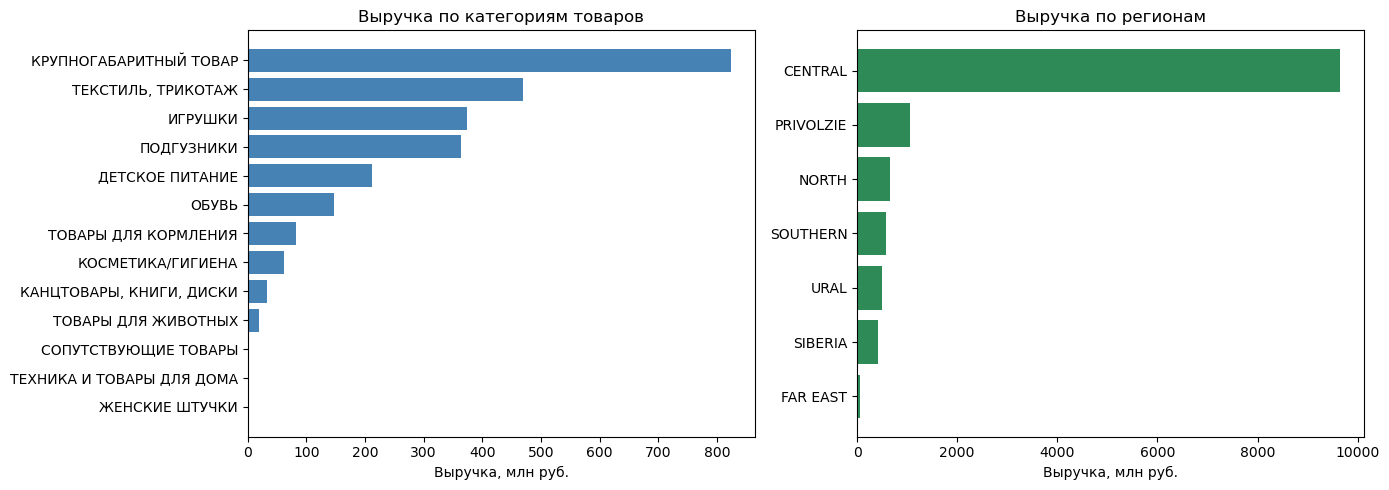

In [88]:
df["СуммаСтроки"] = pd.to_numeric(df["СуммаСтроки"], errors="coerce")
# Категории товаров и регионы
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Группа2 — горизонтальный bar
cat = df.groupby("Группа2")["СуммаСтроки"].sum().sort_values()
axes[0].barh(cat.index, cat.values / 1e6, color="steelblue")
axes[0].set_title("Выручка по категориям товаров")
axes[0].set_xlabel("Выручка, млн руб.")

# Регионы
reg = df.groupby("Регион")["СуммаЗаказаНаСайте"].sum().sort_values()
axes[1].barh(reg.index, reg.values / 1e6, color="seagreen")
axes[1].set_title("Выручка по регионам")
axes[1].set_xlabel("Выручка, млн руб.")

plt.tight_layout()
plt.show()